<a href="https://colab.research.google.com/github/Susy47/MarketBasket-Analysis/blob/main/market_basket_imdb_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Dataset Import

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import time
from collections import defaultdict, Counter

In [4]:

os.environ['KAGGLE_USERNAME'] = "xxxxx"
os.environ['KAGGLE_KEY'] = "xxxxx"

!kaggle datasets download -d harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows

!unzip -o imdb-dataset-of-top-1000-movies-and-tv-shows.zip

Dataset URL: https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
License(s): CC0-1.0
imdb-dataset-of-top-1000-movies-and-tv-shows.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  imdb-dataset-of-top-1000-movies-and-tv-shows.zip
  inflating: imdb_top_1000.csv       


# 2. Data structure

In [6]:
data = pd.read_csv('imdb_top_1000.csv')
print(f"Shape: {data.shape[0]} rows, {data.shape[1]} columns")
print(f"\nColumns: {list(data.columns)}")

Shape: 1000 rows, 16 columns

Columns: ['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']


The original dataset contains 1000 rows and 16 columns, but only a few are useful for our analysis.
The columns of our interest in order to conduct the market-basket analysis are: 'Series_Title', representing the title of each movie, and columns 'Star1' to 'Star4', which correspond to the actors starring in the corresponding movie.

In [8]:
# Select only the relevant columns
relevant_cols = ['Series_Title', 'Star1', 'Star2', 'Star3', 'Star4']

print("Sample of relevant columns:")
data[relevant_cols].head(10)

Sample of relevant columns:


,Series_Title,Star1,Star2,Star3,Star4
0,The Shawshank Redemption,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler
1,The Godfather,Marlon Brando,Al Pacino,James Caan,Diane Keaton
2,The Dark Knight,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine
3,The Godfather: Part II,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton
4,12 Angry Men,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler
5,The Lord of the Rings: The Return of the King,Elijah Wood,Viggo Mortensen,Ian McKellen,Orlando Bloom
6,Pulp Fiction,John Travolta,Uma Thurman,Samuel L. Jackson,Bruce Willis
7,Schindler's List,Liam Neeson,Ralph Fiennes,Ben Kingsley,Caroline Goodall
8,Inception,Leonardo DiCaprio,Joseph Gordon-Levitt,Elliot Page,Ken Watanabe
9,Fight Club,Brad Pitt,Edward Norton,Meat Loaf,Zach Grenier


# 3. Data Preprocessing

In [9]:
# Rearrange the dataset keeping only relevant columns
df = data[['Series_Title', 'Star1', 'Star2', 'Star3', 'Star4']]

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1000, 5)


,Series_Title,Star1,Star2,Star3,Star4
0,The Shawshank Redemption,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler
1,The Godfather,Marlon Brando,Al Pacino,James Caan,Diane Keaton
2,The Dark Knight,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine
3,The Godfather: Part II,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton
4,12 Angry Men,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler


## 3.1 Check for Missing values

In [10]:
# Check for missing values in actor columns
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Series_Title    0
Star1           0
Star2           0
Star3           0
Star4           0
dtype: int64


## 3.2 Check for duplicates

In [12]:
# To ensure consistency, we should clean all columns: strip whitespace and lowercase. In this case, we could avoid errors like considering the same actor as different ones just because of uppercase and lowercase mismatches.
df = df.apply(lambda col: col.str.strip().str.lower())

print(f"Total rows: {len(df)}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate titles: {df['Series_Title'].duplicated().sum()}")

print("\nSample after cleaning:")
df.head()

Total rows: 1000
Duplicate rows: 0
Duplicate titles: 1

Sample after cleaning:


,Series_Title,Star1,Star2,Star3,Star4
0,the shawshank redemption,tim robbins,morgan freeman,bob gunton,william sadler
1,the godfather,marlon brando,al pacino,james caan,diane keaton
2,the dark knight,christian bale,heath ledger,aaron eckhart,michael caine
3,the godfather: part ii,al pacino,robert de niro,robert duvall,diane keaton
4,12 angry men,henry fonda,lee j. cobb,martin balsam,john fiedler


We have found no duplicate rows but 1 duplicate title. Since there are no entirely equal rows, this may be due to a case where two movies have be named the same, but they are not related. To check this, let's just take these two rows.

In [16]:
# Find the duplicate title
print("Duplicate title:")
print(data[data['Series_Title'].duplicated(keep=False)][['Series_Title', 'Star1', 'Star2', 'Star3', 'Star4','Released_Year','Director']])

Duplicate title:
    Series_Title       Star1         Star2         Star3         Star4  \
87      Drishyam    Mohanlal         Meena  Asha Sharath        Ansiba   
136     Drishyam  Ajay Devgn  Shriya Saran          Tabu  Rajat Kapoor   

    Released_Year         Director  
87           2013    Jeethu Joseph  
136          2015  Nishikant Kamat  


We can see that these are actually 2 different movies, with different cast and release year. So they are not duplicates, thus we don't have to drop one.
To ensure integrity, we can add a numeric index as identifier for display purposes.

In [18]:
# Reset index to ensure unique identifier for each movie
df = df.reset_index(drop=True)
df.index.name = 'movie_id'

print("Each movie now has a unique numeric ID:")
print(df.loc[[87, 136]])
print(df)

Each movie now has a unique numeric ID:
         Series_Title       Star1         Star2         Star3         Star4
movie_id                                                                   
87           drishyam    mohanlal         meena  asha sharath        ansiba
136          drishyam  ajay devgn  shriya saran          tabu  rajat kapoor
                      Series_Title              Star1              Star2  \
movie_id                                                                   
0         the shawshank redemption        tim robbins     morgan freeman   
1                    the godfather      marlon brando          al pacino   
2                  the dark knight     christian bale       heath ledger   
3           the godfather: part ii          al pacino     robert de niro   
4                     12 angry men        henry fonda        lee j. cobb   
...                            ...                ...                ...   
995         breakfast at tiffany's     audrey he

## 3.3 Basket Transformation

In [19]:
# Build baskets: each movie = one basket, actors = items
actor_cols = ['Star1', 'Star2', 'Star3', 'Star4']

baskets = [set(row) for row in df[actor_cols].values]

print(f"Total baskets: {len(baskets)}")
print(f"\nFirst 3 baskets:")
for i, basket in enumerate(baskets[:3]):
    print(f"  '{df['Series_Title'].iloc[i]}': {basket}")

Total baskets: 1000

First 3 baskets:
  'the shawshank redemption': {'tim robbins', 'morgan freeman', 'william sadler', 'bob gunton'}
  'the godfather': {'al pacino', 'james caan', 'marlon brando', 'diane keaton'}
  'the dark knight': {'heath ledger', 'michael caine', 'christian bale', 'aaron eckhart'}


In [26]:
# Integrity validation: verify the two drishyam movies are treated as separate baskets
drishyam_indices = df[df['Series_Title'] == 'drishyam'].index.tolist()

print(f"'drishyam' appears at indices: {drishyam_indices}")
print(f"\nBasket {drishyam_indices[0]}: {baskets[drishyam_indices[0]]}")
print(f"Basket {drishyam_indices[1]}: {baskets[drishyam_indices[1]]}")
print(f"\nAre they the same basket? {baskets[drishyam_indices[0]] == baskets[drishyam_indices[1]]}")

'drishyam' appears at indices: [87, 136]

Basket 87: {'asha sharath', 'ansiba', 'meena', 'mohanlal'}
Basket 136: {'tabu', 'rajat kapoor', 'ajay devgn', 'shriya saran'}

Are they the same basket? False


# 4. Algorithms

## 4.1 Support Threshold
Before running the algorithms, we explore the data to understand
actor frequency distribution and choose an appropriate support threshold.

In [20]:
# Count how many movies each actor appears in
all_actors = [actor for basket in baskets for actor in basket]
actor_counts = Counter(all_actors)

print(f"Total unique actors: {len(actor_counts)}")
print(f"\nTop 10 most frequent actors:")
for actor, count in actor_counts.most_common(10):
    print(f"  {actor:<30} {count} movies")

Total unique actors: 2709

Top 10 most frequent actors:
  robert de niro                 17 movies
  tom hanks                      14 movies
  al pacino                      13 movies
  brad pitt                      12 movies
  clint eastwood                 12 movies
  christian bale                 11 movies
  leonardo dicaprio              11 movies
  matt damon                     11 movies
  james stewart                  10 movies
  michael caine                  9 movies


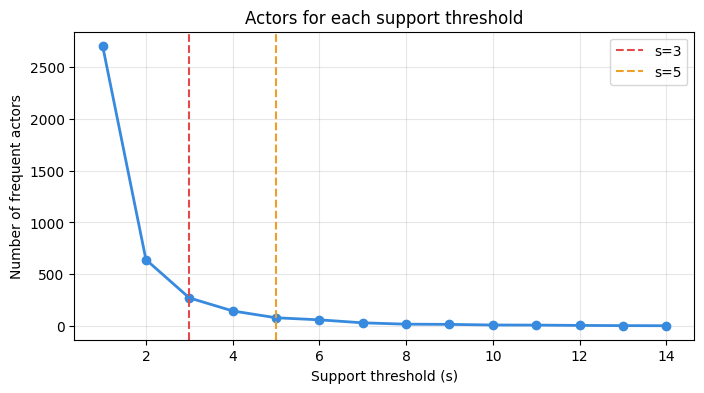

Actors surviving each threshold:
  s=2: 641 frequent actors
  s=3: 271 frequent actors
  s=4: 145 frequent actors
  s=5: 79 frequent actors
  s=6: 59 frequent actors
  s=7: 30 frequent actors
  s=8: 17 frequent actors


In [21]:
# To choose the threshold, we check quickly how many frequent actors there are for s = 1 to 15.
thresholds = range(1, 15)
surviving = [sum(1 for c in actor_counts.values() if c >= t) for t in thresholds]

plt.figure(figsize=(8, 4))
plt.plot(list(thresholds), surviving, marker='o', color='#378ADD', linewidth=2)
plt.axvline(x=3, color='#E24B4A', linestyle='--', label='s=3')
plt.axvline(x=5, color='#EF9F27', linestyle='--', label='s=5')
plt.xlabel('Support threshold (s)')
plt.ylabel('Number of frequent actors')
plt.title('Actors for each support threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print exact numbers for a few thresholds
print("Actors surviving each threshold:")
for t in [2, 3, 4, 5, 6, 7, 8]:
    n = sum(1 for c in actor_counts.values() if c >= t)
    print(f"  s={t}: {n} frequent actors")

Let's start by considering s=3 as the default threshold.
It seems to be strict enough to filter out actors who appear in only 1-2 movies, while leaving enough actors (271) to find interesting combinations.

In [22]:
# Global variable for support threshold
# It is possible then to change this value to experiment with different thresholds
MIN_SUPPORT = 3

print(f"Support threshold set to: {MIN_SUPPORT}")
print(f"Frequent actors at this threshold: {sum(1 for c in actor_counts.values() if c >= MIN_SUPPORT)}")

Support threshold set to: 3
Frequent actors at this threshold: 271


## 4.2 A-PRIORI Algorithm
The A-Priori algorithm finds all frequent itemsets by exploiting **monotonicity**:
if an itemset is frequent, all its subsets must also be frequent.
This allows us to prune the candidate space at each pass.

### 4.2.1 A-Priori: Frequent Singletons


In [25]:
# Pass 1: we count all individual actors and keep frequent ones
singleton_counts = defaultdict(int)

for basket in baskets:
    for actor in basket:
        singleton_counts[frozenset([actor])] += 1

# Filter by min support → L1
L1 = {itemset: count for itemset, count in singleton_counts.items()
      if count >= MIN_SUPPORT}

print(f"Pass 1 — Singletons:")
print(f"  Total unique actors : {len(singleton_counts)}")
print(f"  Frequent actors (L1): {len(L1)}")

Pass 1 — Singletons:
  Total unique actors : 2709
  Frequent actors (L1): 271


### 4.2.2 A-Priori: Frequent Pairs

In [29]:
# Pass 2: we generate candidate pairs from L1 and count them
pair_counts = defaultdict(int)

for basket in baskets:
    frequent_in_basket = basket & {item for itemset in L1 for item in itemset}
    for pair in itertools.combinations(sorted(frequent_in_basket), 2):
        pair_counts[frozenset(pair)] += 1

In [38]:
# Then let's filter by min support → L2
L2 = {itemset: count for itemset, count in pair_counts.items()
      if count >= MIN_SUPPORT}

print(f"Pass 2 — Pairs:")
print(f"  Candidate pairs : {len(pair_counts)}")
print(f"  Frequent pairs (L2): {len(L2)}")
print(f"\nTop 5 frequent pairs:")
for itemset, sup in sorted(L2.items(), key=lambda x: -x[1])[:5]:
    actors = ' & '.join(a.title() for a in itemset)
    print(f"  {actors:<45} support = {sup}")

Pass 2 — Pairs:
  Candidate pairs : 622
  Frequent pairs (L2): 25

Top 5 frequent pairs:
  Rupert Grint & Daniel Radcliffe               support = 6
  Daniel Radcliffe & Emma Watson                support = 5
  Rupert Grint & Emma Watson                    support = 5
  Robert De Niro & Joe Pesci                    support = 4
  Tom Hanks & Tim Allen                         support = 4


### 4.2.3 A-Priori: Frequent Triples

In [32]:
# Pass 3: generate candidate triples from L2 and count them
triple_counts = defaultdict(int)

candidates = set()
L2_list = list(L2.keys())

for i in range(len(L2_list)):
    for j in range(i + 1, len(L2_list)):
        union = L2_list[i] | L2_list[j]
        if len(union) == 3:
            subsets = [frozenset(union - {item}) for item in union]
            if all(s in L2 for s in subsets):
                candidates.add(union)

In [33]:
# Count candidates in baskets
for basket in baskets:
    for candidate in candidates:
        if candidate.issubset(basket):
            triple_counts[candidate] += 1

In [36]:
# Filter by min support → L3
L3 = {itemset: count for itemset, count in triple_counts.items()
      if count >= MIN_SUPPORT}

print(f"Pass 3 — Triples:")
print(f"  Candidate triples   : {len(candidates)}")
print(f"  Frequent triples (L3): {len(L3)}")
print(f"\nFrequent triples:")
for itemset, sup in sorted(L3.items(), key=lambda x: -x[1]):
    actors = ', '.join(a.title() for a in itemset)
    print(f"  {{{actors}}}  support = {sup}")

Pass 3 — Triples:
  Candidate triples   : 4
  Frequent triples (L3): 3

Frequent triples:
  {Rupert Grint, Daniel Radcliffe, Emma Watson}  support = 5
  {Elijah Wood, Orlando Bloom, Ian Mckellen}  support = 3
  {Mark Hamill, Harrison Ford, Carrie Fisher}  support = 3


### 4.2.4 A-Priori: Check for quadruples

In [39]:
# Pass 4: check if any frequent quadruples exist
quad_counts = defaultdict(int)
candidates = set()
L3_list = list(L3.keys())

for i in range(len(L3_list)):
    for j in range(i + 1, len(L3_list)):
        union = L3_list[i] | L3_list[j]
        if len(union) == 4:
            subsets = [frozenset(union - {item}) for item in union]
            if all(s in L3 for s in subsets):
                candidates.add(union)

print(f"Pass 4 — Quadruples:")
print(f"  Candidate quadruples: {len(candidates)}")
print("  → No frequent quadruples, algorithm stops here.")

Pass 4 — Quadruples:
  Candidate quadruples: 0
  → No frequent quadruples, algorithm stops here.


In [40]:
#Summary : collect all frequent itemsets
all_frequent = {}
all_frequent.update(L1)
all_frequent.update(L2)
all_frequent.update(L3)

print(f"=== A-Priori Results Summary ===")
print(f"  Min support         : {MIN_SUPPORT}")
print(f"  Frequent singletons : {len(L1)}")
print(f"  Frequent pairs      : {len(L2)}")
print(f"  Frequent triples    : {len(L3)}")
print(f"  Total               : {len(all_frequent)}")

=== A-Priori Results Summary ===
  Min support         : 3
  Frequent singletons : 271
  Frequent pairs      : 25
  Frequent triples    : 3
  Total               : 299


### 4.2.5 A-Priori: Association Rules
From the frequent itemsets found by A-Priori, we extract association rules
of the form **I → j**, meaning: "if a movie features actors in I,
it likely also features actor j".

For each rule we compute:
- **Support**: how many movies contain all actors in the rule
- **Confidence**: support(I ∪ {j}) / support(I)
- **Interest**: confidence - P(j), measures if the rule is truly meaningful

In [43]:
def extract_association_rules(all_frequent, n_baskets):

    rules = []

    for itemset, sup_IJ in all_frequent.items():
        if len(itemset) < 2:
            continue

        for j in itemset:
            # Rule: itemset - {j} -> j
            I = itemset - frozenset([j])
            sup_I = all_frequent.get(I)

            if sup_I is None:
                continue

            # Confidence = support(I ∪ {j}) / support(I)
            confidence = sup_IJ / sup_I

            # Interest = confidence - P(j)
            sup_j = all_frequent.get(frozenset([j]), 0)
            p_j = sup_j / n_baskets
            interest = confidence - p_j

            rules.append({
                'antecedent': I,
                'consequent': frozenset([j]),
                'support': sup_IJ,
                'confidence': round(confidence, 4),
                'interest': round(interest, 4)
            })

    # Sort by confidence descending
    rules.sort(key=lambda x: -x['confidence'])
    return rules

In [44]:
rules = extract_association_rules(all_frequent, len(baskets))

print(f"Total association rules found: {len(rules)}")
print(f"Showing top 25 by confidence:\n")
print(f"{'Antecedent':<40} {'→ Consequent':<25} {'Conf':>6} {'Interest':>9} {'Sup':>5}")
print('-' * 90)
for r in rules[:25]:
    ant = ', '.join(a.title() for a in r['antecedent'])
    con = ', '.join(a.title() for a in r['consequent'])
    print(f"{ant:<40} → {con:<23} {r['confidence']:>6.2%} {r['interest']:>+9.4f} {r['support']:>5}")

Total association rules found: 59
Showing top 25 by confidence:

Antecedent                               → Consequent                Conf  Interest   Sup
------------------------------------------------------------------------------------------
Elijah Wood                              → Ian Mckellen            100.00%   +0.9930     3
Elijah Wood                              → Orlando Bloom           100.00%   +0.9960     3
Mark Hamill                              → Carrie Fisher           100.00%   +0.9960     3
Mark Hamill                              → Harrison Ford           100.00%   +0.9920     3
Tim Allen                                → Tom Hanks               100.00%   +0.9860     4
Daniel Radcliffe                         → Rupert Grint            100.00%   +0.9940     6
Rupert Grint                             → Daniel Radcliffe        100.00%   +0.9940     6
John Turturro                            → Ethan Coen              100.00%   +0.9940     3
Orlando Bloom, Ian Mckelle

## 4.3 PCY Algorithm

PCY (Park, Chen, Yu) improves on A-Priori by making smarter use of
available memory during Pass 1.

While A-Priori only counts singletons in Pass 1, PCY **also hashes
every pair into a hash table**. After Pass 1:
- Buckets with count >= s → **frequent bucket** (bit = 1)
- Buckets with count < s → **infrequent bucket** (bit = 0)

In Pass 2, a pair is only counted if:
1. Both actors are in L1 (same as A-Priori)
2. The pair hashes to a **frequent bucket**

This reduces the number of pairs that need to be counted in Pass 2.

### PCY: Pass 1

In [45]:
# PCY Pass 1: count singletons + hash all pairs into a hash table
NUM_BUCKETS = 1000

item_counts = defaultdict(int)
bucket_counts = np.zeros(NUM_BUCKETS, dtype=np.int32)

for basket in baskets:
    # Count individual actors
    for actor in basket:
        item_counts[actor] += 1
    # Hash every pair into a bucket
    for pair in itertools.combinations(sorted(basket), 2):
        bucket = hash(pair) % NUM_BUCKETS
        bucket_counts[bucket] += 1

In [46]:
# Frequent actors L1
L1_pcy = {frozenset([actor]) for actor, count in item_counts.items()
           if count >= MIN_SUPPORT}

bitmap = (bucket_counts >= MIN_SUPPORT)

print(f"PCY Pass 1:")
print(f"  Frequent actors (L1)  : {len(L1_pcy)}")
print(f"  Total buckets         : {NUM_BUCKETS}")
print(f"  Frequent buckets      : {bitmap.sum()} ({100*bitmap.sum()/NUM_BUCKETS:.1f}%)")
print(f"  Infrequent buckets    : {(~bitmap).sum()} ({100*(~bitmap).sum()/NUM_BUCKETS:.1f}%)")

#This is actually expected for our small dataset. With only 1000 movies and 4 actors each, there aren't many pairs, so most buckets don't get overloaded. The PCY filtering effect will be modest here — but on a larger dataset with millions of baskets, many more buckets would be infrequent, and PCY would filter out many more pairs.
#This is actually a great point to make in your report for the scalability section!


PCY Pass 1:
  Frequent actors (L1)  : 271
  Total buckets         : 1000
  Frequent buckets      : 928 (92.8%)
  Infrequent buckets    : 72 (7.2%)


### PCY: Pass 2

In [47]:
# PCY Pass 2: count only pairs where both actors in L1 AND pair hashes to frequent bucket
pair_counts_pcy = defaultdict(int)
total_candidates = 0
pcy_filtered = 0

frequent_actors = {item for itemset in L1_pcy for item in itemset}

for basket in baskets:
    frequent_in_basket = basket & frequent_actors
    for pair in itertools.combinations(sorted(frequent_in_basket), 2):
        total_candidates += 1
        bucket = hash(pair) % NUM_BUCKETS
        if bitmap[bucket]:  # PCY filter
            pair_counts_pcy[frozenset(pair)] += 1
        else:
            pcy_filtered += 1

# Filter by min support → L2_pcy
L2_pcy = {itemset: count for itemset, count in pair_counts_pcy.items()
           if count >= MIN_SUPPORT}

print(f"PCY Pass 2:")
print(f"  Total candidate pairs     : {total_candidates}")
print(f"  Filtered by PCY bitmap    : {pcy_filtered} ({100*pcy_filtered/total_candidates:.1f}%)")
print(f"  Pairs actually counted    : {total_candidates - pcy_filtered}")
print(f"  Frequent pairs (L2)       : {len(L2_pcy)}")

PCY Pass 2:
  Total candidate pairs     : 719
  Filtered by PCY bitmap    : 16 (2.2%)
  Pairs actually counted    : 703
  Frequent pairs (L2)       : 25


### Note on Association Rules
Since A-Priori and PCY produce identical frequent itemsets (as verified above),
the association rules extracted in Section 5 apply to both algorithms.
PCY is purely an efficiency improvement — it reduces the number of candidate
pairs counted in Pass 2, but does not affect the final results.

## 4.4 Comparison between A-Priori and PCY Algorithms
### 4.4.1 Correctness check


In [48]:
# Correctness check: PCY and A-Priori should find the same frequent pairs
apriori_pairs_set = set(L2.keys())
pcy_pairs_set = set(L2_pcy.keys())

print(f"A-Priori frequent pairs : {len(apriori_pairs_set)}")
print(f"PCY frequent pairs      : {len(pcy_pairs_set)}")
print(f"Results are identical   : {apriori_pairs_set == pcy_pairs_set}")

A-Priori frequent pairs : 25
PCY frequent pairs      : 25
Results are identical   : True


### 4.4.2 Timing comparison

In [49]:
# Time A-Priori
start = time.time()

singleton_counts_t = defaultdict(int)
for basket in baskets:
    for actor in basket:
        singleton_counts_t[frozenset([actor])] += 1
L1_t = {k: v for k, v in singleton_counts_t.items() if v >= MIN_SUPPORT}

pair_counts_t = defaultdict(int)
frequent_actors_t = {item for itemset in L1_t for item in itemset}
for basket in baskets:
    frequent_in_basket = basket & frequent_actors_t
    for pair in itertools.combinations(sorted(frequent_in_basket), 2):
        pair_counts_t[frozenset(pair)] += 1
L2_t = {k: v for k, v in pair_counts_t.items() if v >= MIN_SUPPORT}

apriori_time = time.time() - start

In [50]:
# Time PCY
start = time.time()

item_counts_t = defaultdict(int)
bucket_counts_t = np.zeros(NUM_BUCKETS, dtype=np.int32)
for basket in baskets:
    for actor in basket:
        item_counts_t[actor] += 1
    for pair in itertools.combinations(sorted(basket), 2):
        bucket = hash(pair) % NUM_BUCKETS
        bucket_counts_t[bucket] += 1
L1_pcy_t = {frozenset([a]) for a, c in item_counts_t.items() if c >= MIN_SUPPORT}
bitmap_t = (bucket_counts_t >= MIN_SUPPORT)

pair_counts_pcy_t = defaultdict(int)
frequent_actors_pcy = {item for itemset in L1_pcy_t for item in itemset}
for basket in baskets:
    frequent_in_basket = basket & frequent_actors_pcy
    for pair in itertools.combinations(sorted(frequent_in_basket), 2):
        bucket = hash(pair) % NUM_BUCKETS
        if bitmap_t[bucket]:
            pair_counts_pcy_t[frozenset(pair)] += 1

pcy_time = time.time() - start

print(f"A-Priori time : {apriori_time:.4f}s")
print(f"PCY time      : {pcy_time:.4f}s")
print(f"Difference    : {abs(apriori_time - pcy_time):.4f}s")

A-Priori time : 0.0058s
PCY time      : 0.0161s
Difference    : 0.0103s


# 5. Scalability Analysis

We test both algorithms on increasing fractions of the dataset
to analyze how runtime scales with data size.
This demonstrates that our solution can handle larger datasets.

## 5.1 A-Priori Scalability
We run the full A-Priori algorithm on increasing dataset sizes,
obtained by replicating the original baskets.

In [53]:
scale_factors = [1, 10, 100, 500, 1000]
apriori_times_scaled = []
apriori_results = []
n_baskets_scaled = []

for scale in scale_factors:
    scaled_baskets = baskets * scale
    scaled_support = MIN_SUPPORT * scale
    n_baskets_scaled.append(len(scaled_baskets))

    start = time.time()

    # Pass 1 - Singletons
    sc = defaultdict(int)
    for basket in scaled_baskets:
        for actor in basket:
            sc[frozenset([actor])] += 1
    l1 = {k: v for k, v in sc.items() if v >= scaled_support}

    # Pass 2 - Pairs
    freq = {item for itemset in l1 for item in itemset}
    pc = defaultdict(int)
    for basket in scaled_baskets:
        fib = basket & freq
        for pair in itertools.combinations(sorted(fib), 2):
            pc[frozenset(pair)] += 1
    l2 = {k: v for k, v in pc.items() if v >= scaled_support}

    # Pass 3 - Triples
    tc = defaultdict(int)
    candidates = set()
    l2_list = list(l2.keys())
    for i in range(len(l2_list)):
        for j in range(i + 1, len(l2_list)):
            union = l2_list[i] | l2_list[j]
            if len(union) == 3:
                subsets = [frozenset(union - {item}) for item in union]
                if all(s in l2 for s in subsets):
                    candidates.add(union)
    for basket in scaled_baskets:
        for candidate in candidates:
            if candidate.issubset(basket):
                tc[candidate] += 1
    l3 = {k: v for k, v in tc.items() if v >= scaled_support}

    elapsed = time.time() - start
    apriori_times_scaled.append(elapsed)
    apriori_results.append({'L1': len(l1), 'L2': len(l2), 'L3': len(l3)})

    print(f"  {scale:>4}x ({len(scaled_baskets):>7} baskets) "
          f"support={scaled_support}: "
          f"L1={len(l1)}, L2={len(l2)}, L3={len(l3)} "
          f"→ {elapsed:.3f}s")

     1x (   1000 baskets) support=3: L1=271, L2=25, L3=3 → 0.011s
    10x (  10000 baskets) support=30: L1=271, L2=25, L3=3 → 0.041s
   100x ( 100000 baskets) support=300: L1=271, L2=25, L3=3 → 0.413s
   500x ( 500000 baskets) support=1500: L1=271, L2=25, L3=3 → 2.860s
  1000x (1000000 baskets) support=3000: L1=271, L2=25, L3=3 → 4.816s


### 5.2 PCY Scalability
We run the PCY algorithm on the same scaled datasets.

In [58]:
pcy_times_scaled = []
pcy_results = []

for scale in scale_factors:
    scaled_baskets = baskets * scale
    scaled_support = MIN_SUPPORT * scale

    start = time.time()

    # Pass 1 - Count singletons + hash pairs
    ic = defaultdict(int)
    bc = np.zeros(NUM_BUCKETS, dtype=np.int32)
    for basket in scaled_baskets:
        for actor in basket:
            ic[actor] += 1
        for pair in itertools.combinations(sorted(basket), 2):
            bc[hash(pair) % NUM_BUCKETS] += 1

    # Frequent actors and bitmap
    l1p = {frozenset([a]) for a, c in ic.items() if c >= scaled_support}
    bm = (bc >= scaled_support)
    freqp = {item for itemset in l1p for item in itemset}

    # Pass 2 - Count pairs filtered by bitmap
    pcc = defaultdict(int)
    total = 0
    filtered = 0
    for basket in scaled_baskets:
        fib = basket & freqp
        for pair in itertools.combinations(sorted(fib), 2):
            total += 1
            bucket = hash(pair) % NUM_BUCKETS
            if bm[bucket]:
                pcc[frozenset(pair)] += 1
            else:
                filtered += 1
    l2p = {k: v for k, v in pcc.items() if v >= scaled_support}

    # Pass 3 - Triples (same as A-Priori)
    tc = defaultdict(int)
    candidates = set()
    l2p_list = list(l2p.keys())
    for i in range(len(l2p_list)):
        for j in range(i + 1, len(l2p_list)):
            union = l2p_list[i] | l2p_list[j]
            if len(union) == 3:
                subsets = [frozenset(union - {item}) for item in union]
                if all(s in l2p for s in subsets):
                    candidates.add(union)
    for basket in scaled_baskets:
        for candidate in candidates:
            if candidate.issubset(basket):
                tc[candidate] += 1
    l3p = {k: v for k, v in tc.items() if v >= scaled_support}

    elapsed = time.time() - start
    pcy_times_scaled.append(elapsed)
    pcy_results.append({'L1': len(l1p), 'L2': len(l2p), 'L3': len(l3p),
                        'filtered': filtered, 'total': total})

    print(f"  {scale:>4}x ({len(scaled_baskets):>7} baskets) "
          f"support={scaled_support}: "
          f"L1={len(l1p)}, L2={len(l2p)}, L3={len(l3p)} "
          f"filtered={filtered}/{total} ({100*filtered/max(total,1):.1f}%) "
          f"→ {elapsed:.3f}s")

     1x (   1000 baskets) support=3: L1=271, L2=25, L3=3 filtered=16/719 (2.2%) → 0.011s
    10x (  10000 baskets) support=30: L1=271, L2=25, L3=3 filtered=160/7190 (2.2%) → 0.083s
   100x ( 100000 baskets) support=300: L1=271, L2=25, L3=3 filtered=1600/71900 (2.2%) → 0.807s
   500x ( 500000 baskets) support=1500: L1=271, L2=25, L3=3 filtered=8000/359500 (2.2%) → 4.182s
  1000x (1000000 baskets) support=3000: L1=271, L2=25, L3=3 filtered=16000/719000 (2.2%) → 9.466s


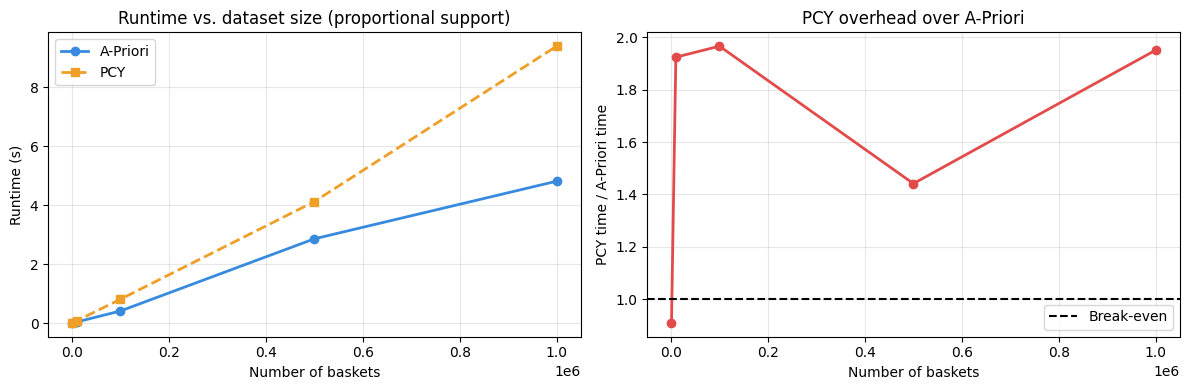

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Runtime comparison
axes[0].plot(n_baskets_scaled, apriori_times_scaled, marker='o',
             label='A-Priori', color='#378ADD', linewidth=2)
axes[0].plot(n_baskets_scaled, pcy_times_scaled, marker='s',
             label='PCY', color='#EF9F27', linewidth=2, linestyle='--')
axes[0].set_xlabel('Number of baskets')
axes[0].set_ylabel('Runtime (s)')
axes[0].set_title('Runtime vs. dataset size (proportional support)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: PCY overhead
overhead = [p/a for a, p in zip(apriori_times_scaled, pcy_times_scaled)]
axes[1].plot(n_baskets_scaled, overhead, marker='o',
             color='#E24B4A', linewidth=2)
axes[1].axhline(y=1.0, color='black', linestyle='--', label='Break-even')
axes[1].set_xlabel('Number of baskets')
axes[1].set_ylabel('PCY time / A-Priori time')
axes[1].set_title('PCY overhead over A-Priori')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [59]:
# Test with higher support thresholds on scaled data
high_supports = [10, 20, 50, 100]
scale = 100  # use 100x scaled data
scaled_baskets = baskets * scale

print(f"Dataset: {len(scaled_baskets)} baskets (100x scaled)\n")
print(f"{'Support':>10} {'Freq Buckets':>15} {'Infreq Buckets':>15} {'Filter Rate':>12} {'A-Priori':>10} {'PCY':>10}")
print('-' * 80)

for sup in high_supports:
    # Build hash table
    ic = defaultdict(int)
    bc = np.zeros(NUM_BUCKETS, dtype=np.int32)
    for basket in scaled_baskets:
        for actor in basket:
            ic[actor] += 1
        for pair in itertools.combinations(sorted(basket), 2):
            bc[hash(pair) % NUM_BUCKETS] += 1
    bm = (bc >= sup)

    # A-Priori timing
    start = time.time()
    freq = {a for a, c in ic.items() if c >= sup}
    pc = defaultdict(int)
    for basket in scaled_baskets:
        fib = basket & freq
        for pair in itertools.combinations(sorted(fib), 2):
            pc[frozenset(pair)] += 1
    l2_ap = {k: v for k, v in pc.items() if v >= sup}
    apriori_t = time.time() - start

    # PCY timing
    start = time.time()
    freqp = {a for a, c in ic.items() if c >= sup}
    pcc = defaultdict(int)
    filtered = 0
    total = 0
    for basket in scaled_baskets:
        fib = basket & freqp
        for pair in itertools.combinations(sorted(fib), 2):
            total += 1
            if bm[hash(pair) % NUM_BUCKETS]:
                pcc[frozenset(pair)] += 1
            else:
                filtered += 1
    pcy_t = time.time() - start

    print(f"  {sup:>8} {bm.sum():>15} {(~bm).sum():>15} "
          f"{100*filtered/max(total,1):>11.1f}% "
          f"{apriori_t:>10.3f}s {pcy_t:>10.3f}s")

Dataset: 100000 baskets (100x scaled)

   Support    Freq Buckets  Infreq Buckets  Filter Rate   A-Priori        PCY
--------------------------------------------------------------------------------
        10             998               2         0.0%      0.746s      0.851s
        20             998               2         0.0%      0.473s      0.747s
        50             998               2         0.0%      0.472s      0.734s
       100             998               2         0.0%      0.458s      0.763s


In [60]:
# Test with larger hash table to show PCY advantage
large_buckets = [1000, 10000, 100000, 500000]
scale = 100
scaled_baskets = baskets * scale

print(f"Dataset: {len(scaled_baskets)} baskets, support=300\n")
print(f"{'Num Buckets':>12} {'Infreq Buckets':>15} {'Filter Rate':>12} {'A-Priori':>10} {'PCY':>10}")
print('-' * 70)

sup = 300  # proportional support

for num_buckets in large_buckets:
    # Build hash table
    ic = defaultdict(int)
    bc = np.zeros(num_buckets, dtype=np.int32)
    for basket in scaled_baskets:
        for actor in basket:
            ic[actor] += 1
        for pair in itertools.combinations(sorted(basket), 2):
            bc[hash(pair) % num_buckets] += 1
    bm = (bc >= sup)

    # A-Priori timing
    start = time.time()
    freq = {a for a, c in ic.items() if c >= sup}
    pc = defaultdict(int)
    for basket in scaled_baskets:
        fib = basket & freq
        for pair in itertools.combinations(sorted(fib), 2):
            pc[frozenset(pair)] += 1
    apriori_t = time.time() - start

    # PCY timing
    start = time.time()
    pcc = defaultdict(int)
    filtered = 0
    total = 0
    for basket in scaled_baskets:
        fib = basket & freq
        for pair in itertools.combinations(sorted(fib), 2):
            total += 1
            if bm[hash(pair) % num_buckets]:
                pcc[frozenset(pair)] += 1
            else:
                filtered += 1
    pcy_t = time.time() - start

    print(f"  {num_buckets:>10} {(~bm).sum():>15} "
          f"{100*filtered/max(total,1):>11.1f}% "
          f"{apriori_t:>10.3f}s {pcy_t:>10.3f}s")

Dataset: 100000 baskets, support=300

 Num Buckets  Infreq Buckets  Filter Rate   A-Priori        PCY
----------------------------------------------------------------------
        1000              72         2.2%      0.129s      0.161s
       10000            9717        71.3%      0.225s      0.248s
      100000           99964        87.1%      0.222s      0.228s
      500000          499972        87.9%      0.127s      0.131s


### Key Insight on PCY and Hash Table Size

- **Larger hash table → more infrequent buckets → higher filter rate**
- With 500,000 buckets, PCY filters **87.9%** of candidate pairs
- PCY's total time advantage appears when Pass 2 is the bottleneck,
  i.e. when there are many frequent items and pairs to count
- On this small dataset, Pass 2 is already fast so the hashing
  overhead in Pass 1 dominates
- On a real large-scale dataset, filtering 87.9% of pairs would
  result in significant speedup

In [61]:
print(f"========================================")
print(f"         RESULTS SUMMARY                ")
print(f"========================================")
print(f"  Dataset             : IMDB Top 1000 Movies")
print(f"  Total baskets       : {len(baskets)}")
print(f"  Total unique actors : {len(actor_counts)}")
print(f"  Support threshold   : {MIN_SUPPORT}")
print(f"----------------------------------------")
print(f"  A-PRIORI RESULTS")
print(f"  Frequent singletons : {len(L1)}")
print(f"  Frequent pairs      : {len(L2)}")
print(f"  Frequent triples    : {len(L3)}")
print(f"  Total itemsets      : {len(all_frequent)}")
print(f"  Association rules   : {len(rules)}")
print(f"----------------------------------------")
print(f"  PCY RESULTS")
print(f"  Frequent pairs      : {len(L2_pcy)}")
print(f"  Pairs filtered      : {pcy_filtered}/{total_candidates} ({100*pcy_filtered/total_candidates:.1f}%)")
print(f"  Results identical   : {set(L2.keys()) == set(L2_pcy.keys())}")
print(f"========================================")

         RESULTS SUMMARY                
  Dataset             : IMDB Top 1000 Movies
  Total baskets       : 1000
  Total unique actors : 2709
  Support threshold   : 3
----------------------------------------
  A-PRIORI RESULTS
  Frequent singletons : 271
  Frequent pairs      : 25
  Frequent triples    : 3
  Total itemsets      : 299
  Association rules   : 59
----------------------------------------
  PCY RESULTS
  Frequent pairs      : 25
  Pairs filtered      : 16/719 (2.2%)
  Results identical   : True
